#### Generate Progressive Parkinson's Disease Astrocyte Morphologies

Create progressively pruned Astrocyte morphologies from healthy segmented Astrocyte maps by selectively reducing thin-process area and perimeter while preserving soma and major branch structure. 

Generate multiple disease-severity stages and save both segmentation maps and visualization images for downstream simulations.

#### Generate Progressive Astrocyte Pruning Variants

1. Compute target pruning levels based on area and perimeter retention

2. Progressively erode thin processes while protecting regions near the soma and thick branches

3. Generate multiple Parkinson's disease severity stages

4. Save the resulting segmentation maps

5. Create side-by-side visualizations comparing healthy and pruned morphologies


Processing: Healthy_astro_1_stitched.npy
  ➤ Step 1: Healthy → (80%, 85%)
  ➤ Saved PD mask visualization: Step_4_PD_Masks/astro_1_80_85_pd_mask.png


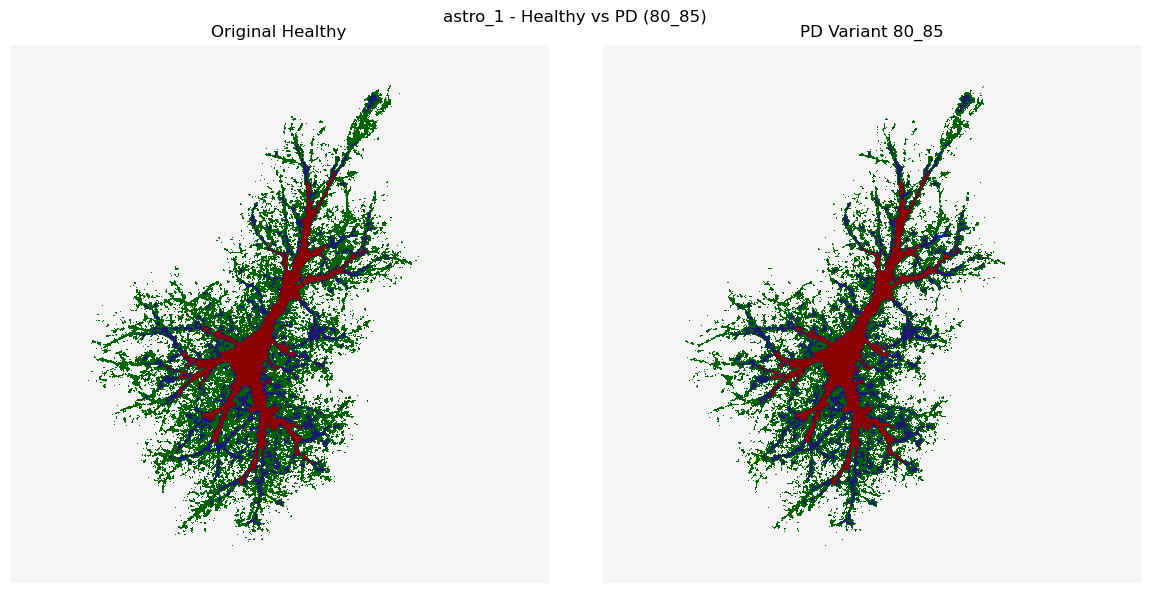

  ➤ Step 2: (80→60, 85→70) → (77.9%, 72.9%) of input
  ➤ Saved PD mask visualization: Step_4_PD_Masks/astro_1_60_70_pd_mask.png


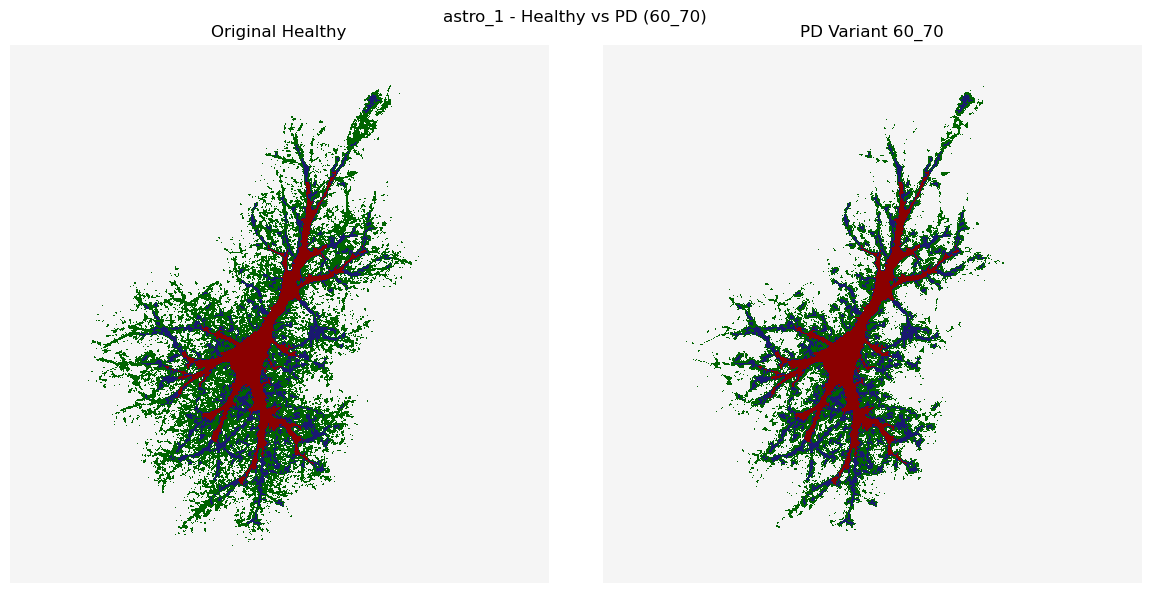

  ➤ Step 3: (60→40, 70→55) → (67.3%, 73.6%) of input
  ➤ Saved PD mask visualization: Step_4_PD_Masks/astro_1_40_55_pd_mask.png


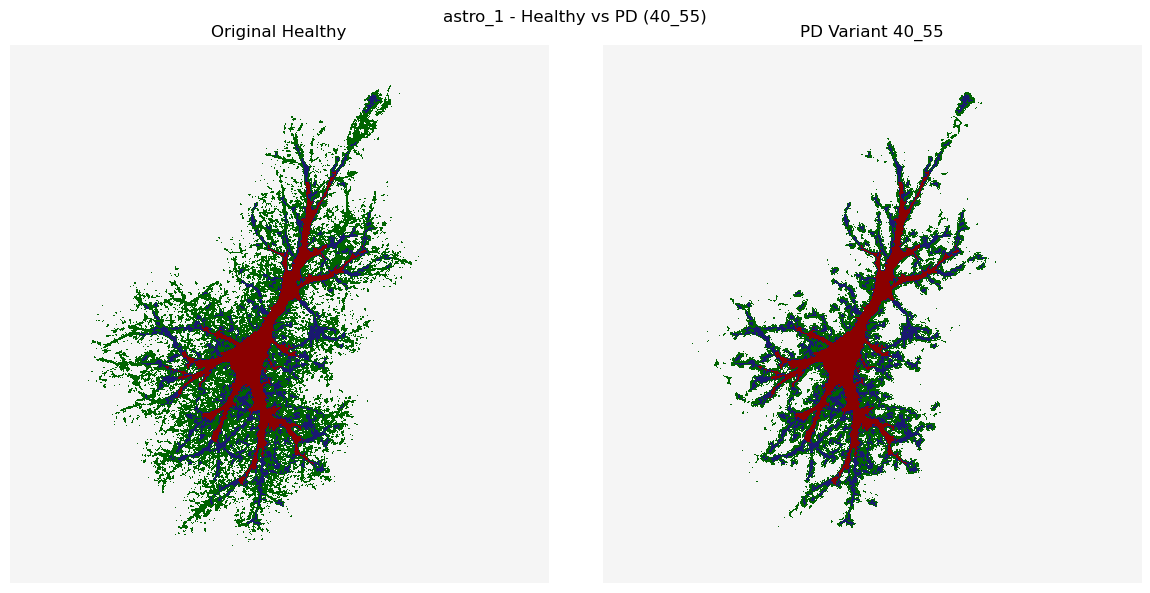


 All progressive PD astrocyte files generated.


In [1]:
import numpy as np
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from skimage.morphology import erosion, disk
from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt
from skimage.measure import perimeter

# ========================================
# Load Healthy Astrocyte Data
# ========================================
def load_npy(file_path):
    return np.load(file_path)

# ========================================
# Compute Power Law Scaling Factors
# ========================================
def compute_pruning_factors(area_retention_percent, perimeter_retention_percent):
    # Compute the severity of pruning based on area and perimeter retention
    perimeter_scaling_factor = (1 - (perimeter_retention_percent / 100)) * 3  
    erosion_kernel_size = max(3, int(perimeter_scaling_factor * 6))  
    num_erosion_passes = max(1, int(4 * (1 - perimeter_retention_percent / 100)))
    
    return erosion_kernel_size, num_erosion_passes

def prune_thin_processes_combined(image, erosion_kernel_size, num_erosion_passes, protect_within=15, target_area_percent=40, target_perimeter_percent=55):
    soma_mask = image == 0
    thick_mask = image == 1
    thin_mask = image == 2

    # Step 1: Protect thin pixels close to thick + soma
    source_mask = soma_mask | thick_mask
    distance_map = distance_transform_edt(~source_mask)
    protected_thin = thin_mask & (distance_map <= protect_within)

    # Step 2: Apply erosion only to unprotected thin pixels
    erodible_thin = thin_mask & ~protected_thin
    pruned = erodible_thin.astype(np.uint8)

    # Step 3: Erosion loop
    for _ in range(num_erosion_passes):
        pruned = erosion(pruned, disk(erosion_kernel_size))

    # Step 4: Otsu threshold to clean up
    if pruned.any():
        threshold = threshold_otsu(pruned)
        eroded_mask = pruned > (threshold * 0.8)
    else:
        eroded_mask = np.zeros_like(pruned, dtype=bool)

    # Step 5: Combine protected + pruned thin
    final_thin = protected_thin | eroded_mask

    # Step 6: Reconstruct label image
    final_image = np.full_like(image, 3)
    final_image[soma_mask] = 0
    final_image[thick_mask] = 1
    final_image[final_thin] = 2

    return final_image

# ========================================
# Create RGB Image
# ========================================
def create_rgb_image(label_image):
    color_map = {
        0: [139/255, 0, 0],           # maroon (soma)
        1: [25/255, 25/255, 112/255], # midnight blue (thick branches)
        2: [0, 100/255, 0],           # dark green (thin processes)
        3: [245/255, 245/255, 245/255] # light gray (background)
    }
    rgb = np.ones((*label_image.shape, 3))
    for label, color in color_map.items():
        rgb[label_image == label] = color
    return rgb

# ========================================
# Visualize and Save Mask
# ========================================
def visualize_and_save_mask(original, processed, output_prefix, suffix, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    orig_rgb = create_rgb_image(original)
    proc_rgb = create_rgb_image(processed)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(orig_rgb, interpolation='none')
    axs[0].set_title("Original Healthy")
    axs[1].imshow(proc_rgb, interpolation='none')
    axs[1].set_title(f"PD Variant {suffix}")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(f"{output_prefix} - Healthy vs PD ({suffix})", fontsize=12)
    plt.tight_layout()

    vis_path = os.path.join(save_dir, f"{output_prefix}_{suffix}_pd_mask.png")
    fig.savefig(vis_path, dpi=150)
    print(f"  ➤ Saved PD mask visualization: {vis_path}")
    plt.show()
    plt.close(fig)

# ======================================================
# Generate Progressive PD Astrocyte Variants
# ======================================================
def generate_pd_npy_relative(input_npy_path, output_prefix, output_dir, vis_dir):
    healthy_image = load_npy(input_npy_path)

    healthy_thin_mask = healthy_image == 2
    A0 = np.sum(healthy_thin_mask)
    P0 = perimeter(healthy_thin_mask.astype(np.uint8))

    # Step 1: Prune healthy → (80%, 85%)
    print(f"  ➤ Step 1: Healthy → (80%, 85%)")
    eros_k1, passes1 = compute_pruning_factors(80, 85)
    pd_80_85 = prune_thin_processes_combined(healthy_image, eros_k1, passes1, protect_within=20)
    A1 = np.sum(pd_80_85 == 2)
    P1 = perimeter((pd_80_85 == 2).astype(np.uint8))
    suffix_1 = "80_85"
    file_1 = f"pd_{output_prefix}_{suffix_1}.npy"
    np.save(os.path.join(output_dir, file_1), pd_80_85)
    visualize_and_save_mask(healthy_image, pd_80_85, output_prefix, suffix_1, vis_dir)

    # Step 2: Prune (80,85) → (60%, 70%) of Healthy
    rel_area_2 = (0.60 * A0) / A1 * 100
    rel_perim_2 = (0.70 * P0) / P1 * 100
    print(f"  ➤ Step 2: (80→60, 85→70) → ({rel_area_2:.1f}%, {rel_perim_2:.1f}%) of input")
    eros_k2, passes2 = compute_pruning_factors(rel_area_2, rel_perim_2)
    pd_60_70 = prune_thin_processes_combined(pd_80_85, eros_k2, passes2, protect_within=20)
    A2 = np.sum(pd_60_70 == 2)
    P2 = perimeter((pd_60_70 == 2).astype(np.uint8))
    suffix_2 = "60_70"
    file_2 = f"pd_{output_prefix}_{suffix_2}.npy"
    np.save(os.path.join(output_dir, file_2), pd_60_70)
    visualize_and_save_mask(healthy_image, pd_60_70, output_prefix, suffix_2, vis_dir)

    # Step 3: Prune (60,70) → (40%, 55%) of Healthy
    rel_area_3 = (0.40 * A0) / A2 * 100
    rel_perim_3 = (0.55 * P0) / P2 * 100
    print(f"  ➤ Step 3: (60→40, 70→55) → ({rel_area_3:.1f}%, {rel_perim_3:.1f}%) of input")
    eros_k3, passes3 = compute_pruning_factors(rel_area_3, rel_perim_3)
    pd_40_55 = prune_thin_processes_combined(pd_60_70, eros_k3, passes3, protect_within=20)
    suffix_3 = "40_55"
    file_3 = f"pd_{output_prefix}_{suffix_3}.npy"
    np.save(os.path.join(output_dir, file_3), pd_40_55)
    visualize_and_save_mask(healthy_image, pd_40_55, output_prefix, suffix_3, vis_dir)

    return [file_1, file_2, file_3]


# ========================================
# Run the Processing
# ========================================

input_dir = "Step_0_Stitched_NPYs"
output_dir = "Step_4_Stitched_PD_NPYs"
vis_dir = "Step_4_PD_Masks"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(vis_dir, exist_ok=True)

for filename in sorted(os.listdir(input_dir)):
    if filename.endswith("_stitched.npy") and filename.startswith("Healthy_astro_"):
        parts = filename.replace(".npy", "").split("_")
        astro_number = parts[2]
        output_prefix = f"astro_{astro_number}"
        input_path = os.path.join(input_dir, filename)
        print(f"\nProcessing: {filename}")
        generate_pd_npy_relative(input_path, output_prefix, output_dir, vis_dir)

print("\n All progressive PD astrocyte files generated.")
